In [2]:
! pip install kagglehub

In [6]:
! pip install wordcloud

In [3]:
import kagglehub
uciml_sms_spam_collection_dataset_path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')
danielwillgeorge_glove6b100dtxt_path = kagglehub.dataset_download('danielwillgeorge/glove6b100dtxt')
andreshg_masksforwordclouds_path = kagglehub.dataset_download('andreshg/masksforwordclouds')
image_source = kagglehub.dataset_download("andreshg/masksforwordclouds")

print('Data source import complete.')

100%|██████████| 211k/211k [00:01<00:00, 183kB/s]

Extracting files...


100%|██████████| 131M/131M [03:50<00:00, 598kB/s]  

Extracting files...


100%|██████████| 198k/198k [00:01<00:00, 168kB/s]

Extracting files...


Data source import complete.


In [4]:
import numpy as np
import pandas as pd
import os

# Traverse through all files inside /kaggle/input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # Print full file path
        print(os.path.join(dirname, filename))

In [7]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter

from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tqdm import tqdm
import os
import nltk
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch

from collections import defaultdict
from collections import Counter

import keras
from keras.models import Sequential
from keras.initializers import Constant
from keras.layers import (LSTM,
                          Embedding,
                          BatchNormalization,
                          Dense,
                          TimeDistributed,
                          Dropout,
                          Bidirectional,
                          Flatten,
                          GlobalMaxPool1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Embedding
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    accuracy_score
)

In [11]:
primary_blue = "#496595"
primary_blue2 = "#85a1c1"
primary_blue3 = "#3f4d63"
primary_grey = "#c6ccd8"
primary_black = "#202022"
primary_bgcolor = "#f4f0ea"
primary_green = px.colors.qualitative.Plotly[:2]

In [9]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Dataset Path:", path)

# List files inside dataset folder
print(os.listdir(path))

Dataset Path: C:\Users\ashmi\.cache\kagglehub\datasets\uciml\sms-spam-collection-dataset\versions\1
['spam.csv']


In [10]:
df = pd.read_csv(os.path.join(path, "spam.csv"), encoding="latin-1")

df = df.dropna(how="any", axis=1)
df.columns = ['target', 'message']

df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df['message_len'] = df['message'].apply(lambda x: len(x.split(' ')))
df.head()

,target,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [13]:
max(df['message_len'])

171

In [14]:
balance_counts = df.groupby('target')['target'].agg('count').values
balance_counts

array([4825,  747], dtype=int64)

In [15]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=['ham'],
    y=[balance_counts[0]],
    name='ham',
    text = [balance_counts[0]],
    textposition = 'auto',
    marker_color=primary_blue
))
fig.add_trace(go.Bar(
    x=['spam'],
    y=[balance_counts[1]],
    name='spam',
    text=[balance_counts[1]],
    textposition = 'auto',
    marker_color=primary_grey
))
fig.update_layout(
    title='<span style="font-size:32px;font-family:Times New Roman">Dataset distribution by target</span>',
    xaxis_title='<span style="font-size:24px;font-family:Times New Roman">Target</span>',
    yaxis_title='<span style="font-size:24px;font-family:Times New Roman">Count</span>',
    barmode='group',
    bargap=0.15,
    bargroupgap=0.1,
)
fig.show()

In [17]:
ham_df = df[df['target'] == 'ham']['message_len'].value_counts().sort_index()
spam_df = df[df['target'] == 'spam']['message_len'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Scatter(

    x = ham_df.index,
    y = ham_df.values,
    name = 'ham',
    fill = 'tozeroy',
    marker_color = primary_blue,
))
fig.add_trace(go.Scatter(
    x = spam_df.index,
    y = spam_df.values,
    name = 'spam',
    fill = 'tozeroy',
    marker_color = primary_grey,
))
fig.update_layout(
    title='Message Length Distribution',
    xaxis_title='Message Length',
    yaxis_title='Count',
    template='plotly_white',
    width=900,
    height=500
)

fig.show()

In [18]:
import re
import string

def clean_text(text):
    '''Make text lowercase, remove text in square brackets, remove links, remove punctuation and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:7: SyntaxWarning:

invalid escape sequence '\['

<>:8: SyntaxWarning:

invalid escape sequence '\S'

<>:12: SyntaxWarning:

invalid escape sequence '\w'

<>:7: SyntaxWarning:

invalid escape sequence '\['

<>:8: SyntaxWarning:

invalid escape sequence '\S'

<>:12: SyntaxWarning:

invalid escape sequence '\w'

C:\Users\ashmi\AppData\Local\Temp\ipykernel_11040\2191709609.py:7: SyntaxWarning:

invalid escape sequence '\['

C:\Users\ashmi\AppData\Local\Temp\ipykernel_11040\2191709609.py:8: SyntaxWarning:

invalid escape sequence '\S'

C:\Users\ashmi\AppData\Local\Temp\ipykernel_11040\2191709609.py:12: SyntaxWarning:

invalid escape sequence '\w'



In [20]:
df['message_clean'] = df['message'].apply(clean_text)
df.head()

,target,message,message_len,message_clean
0,ham,go until jurong point crazy available only in ...,20,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni,6,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...,28,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say,11,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...,13,nah i dont think he goes to usf he lives aroun...


In [22]:
import nltk
nltk.download('stopwords')
stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join([word for word in text.split(' ') if word not in stop_words])
    return text

df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ashmi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,target,message,message_len,message_clean
0,ham,go until jurong point crazy available only in ...,20,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni,6,ok lar joking wif oni
2,spam,free entry in a wkly comp to win fa cup final...,28,free entry wkly comp win fa cup final tkts m...
3,ham,u dun say so early hor u c already then say,11,dun say early hor already say
4,ham,nah i dont think he goes to usf he lives aroun...,13,nah dont think goes usf lives around though


In [23]:
stemmer = nltk.SnowballStemmer("english")

def stemm_text(text):
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
    return text

In [24]:
df['message_clean'] = df['message_clean'].apply(stemm_text)
df.head()

,target,message,message_len,message_clean
0,ham,go until jurong point crazy available only in ...,20,go jurong point crazi avail bugi n great world...
1,ham,ok lar joking wif u oni,6,ok lar joke wif oni
2,spam,free entry in a wkly comp to win fa cup final...,28,free entri wkli comp win fa cup final tkts m...
3,ham,u dun say so early hor u c already then say,11,dun say earli hor alreadi say
4,ham,nah i dont think he goes to usf he lives aroun...,13,nah dont think goe usf live around though


In [25]:
def preprocess_data(text):
    text = clean_text(text)
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
    return text

In [26]:
df['message_clean'] = df['message_clean'].apply(preprocess_data)
df.head()

,target,message,message_len,message_clean
0,ham,go until jurong point crazy available only in ...,20,go jurong point crazi avail bugi n great world...
1,ham,ok lar joking wif u oni,6,ok lar joke wif oni
2,spam,free entry in a wkly comp to win fa cup final...,28,free entri wkli comp win fa cup final tkts m...
3,ham,u dun say so early hor u c already then say,11,dun say ear hor alreadi say
4,ham,nah i dont think he goes to usf he lives aroun...,13,nah dont think goe usf live around though


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df['target'])

df['target_encoded'] = le.transform(df['target'])
df.head()

,target,message,message_len,message_clean,target_encoded
0,ham,go until jurong point crazy available only in ...,20,go jurong point crazi avail bugi n great world...,0
1,ham,ok lar joking wif u oni,6,ok lar joke wif oni,0
2,spam,free entry in a wkly comp to win fa cup final...,28,free entri wkli comp win fa cup final tkts m...,1
3,ham,u dun say so early hor u c already then say,11,dun say ear hor alreadi say,0
4,ham,nah i dont think he goes to usf he lives aroun...,13,nah dont think goe usf live around though,0


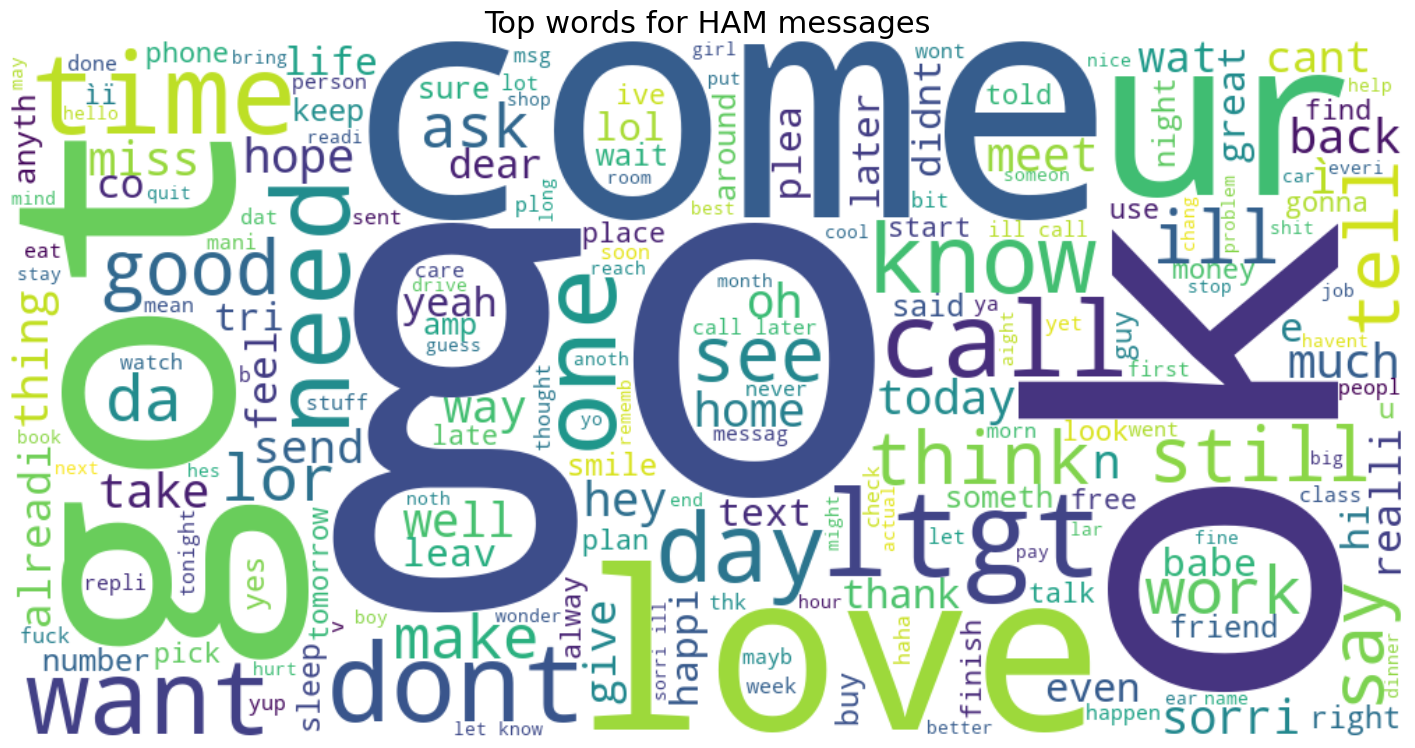

In [ ]:
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

wc = WordCloud(
    background_color='white',
    max_words=200,
    width=1000,
    height=500,
    
)

text = ' '.join(text for text in df.loc[df['target'] == 'ham', 'message_clean'])

wc.generate(text)

plt.figure(figsize=(18, 10))
plt.title(
    'Top words for HAM messages',
    fontdict={'size': 22}
)

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

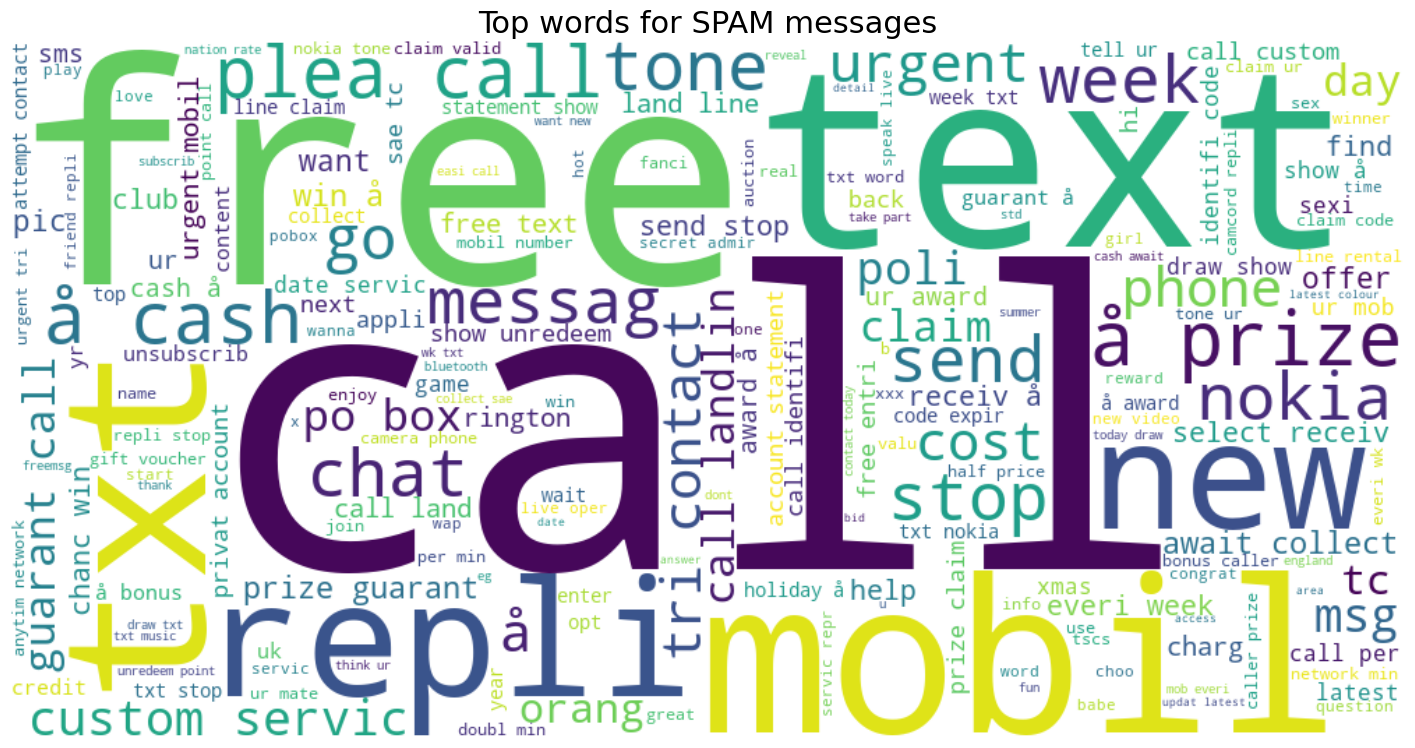

In [ ]:
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

wc = WordCloud(
    background_color='white',
    max_words=200,
    width=1000,
    height=500,
)


text = ' '.join(text for text in df.loc[df['target'] == 'spam', 'message_clean'])

wc.generate(text)

# Display
plt.figure(figsize=(18, 10))
plt.title(
    'Top words for SPAM messages',
    fontdict={'size': 22}
)

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

In [34]:
x = df['message_clean']
y = df['target_encoded']

print(len(x), len(y))

5572 5572


In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)
print(len(x_train), len(y_train))
print(len(x_test), len(y_test))


4179 4179
1393 1393


In [36]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()
vect.fit(x_train)

CountVectorizer()

In [37]:
x_train_dtm = vect.transform(x_train)
x_test_dtm = vect.transform(x_test)

In [39]:
vect_tunned = CountVectorizer(stop_words='english', ngram_range=(1,2), min_df=0.1, max_df=0.7, max_features=100)

In [41]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()

tfidf_transformer.fit(x_train_dtm)
x_train_tfidf = tfidf_transformer.transform(x_train_dtm)

x_train_tfidf

<4179x5684 sparse matrix of type '<class 'numpy.float64'>'
	with 32201 stored elements in Compressed Sparse Row format>

In [42]:
texts = df['message_clean']
target = df['target_encoded']

In [43]:
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(texts)

vocab_length = len(word_tokenizer.word_index)+1
vocab_length

6726

In [ ]:
def embed(corpus):
    